# Baseline Correction

It is known that baseline correction is usually required for SEC-SAXS data. In this chapter, we will explain how to do it in Molass Library with one of the methods below.

* linear (default)
* uvdiff
* integral

## Learning Points
* ssd.plot_compact(baseline=True)
* ssd.corrected_copy()

## Linear Correction

By default, linear baseline is assumed. Before correction, you can confirm how it is determined with basseline option as follows.

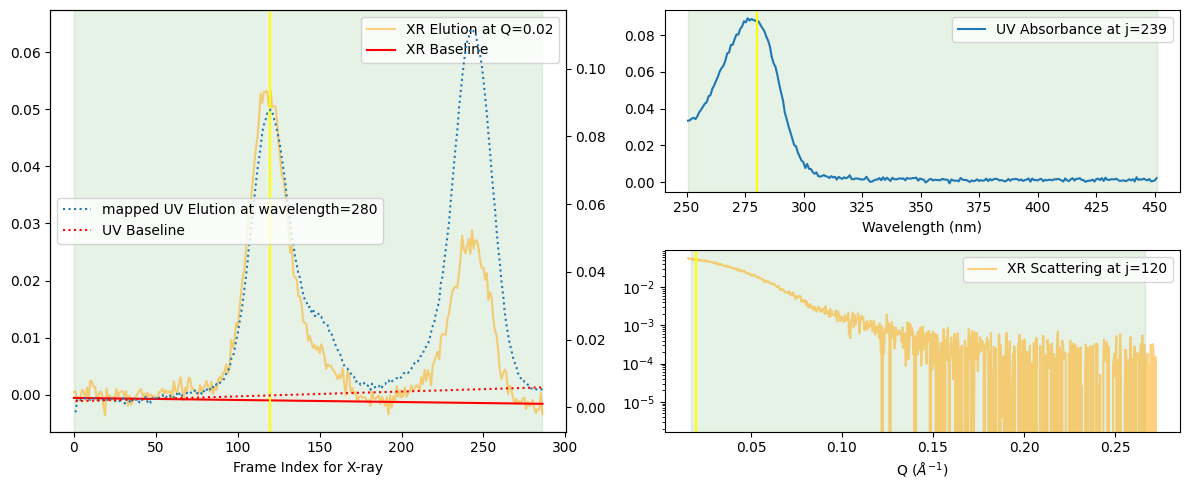

In [1]:
import sys
sys.path.insert(0, '../../../molass-library')
sys.path.insert(0, '../../../molass-legacy')
from molass import get_version
assert get_version() >= '0.1.2', "This tutorial requires molass version 0.1.2 or higher."
from molass_data import SAMPLE1
from molass.DataObjects import SecSaxsData as SSD
ssd = SSD(SAMPLE1)
ssd.plot_compact(baseline=True);

Actual correction is performed with the `corrected_copy` as shown below.

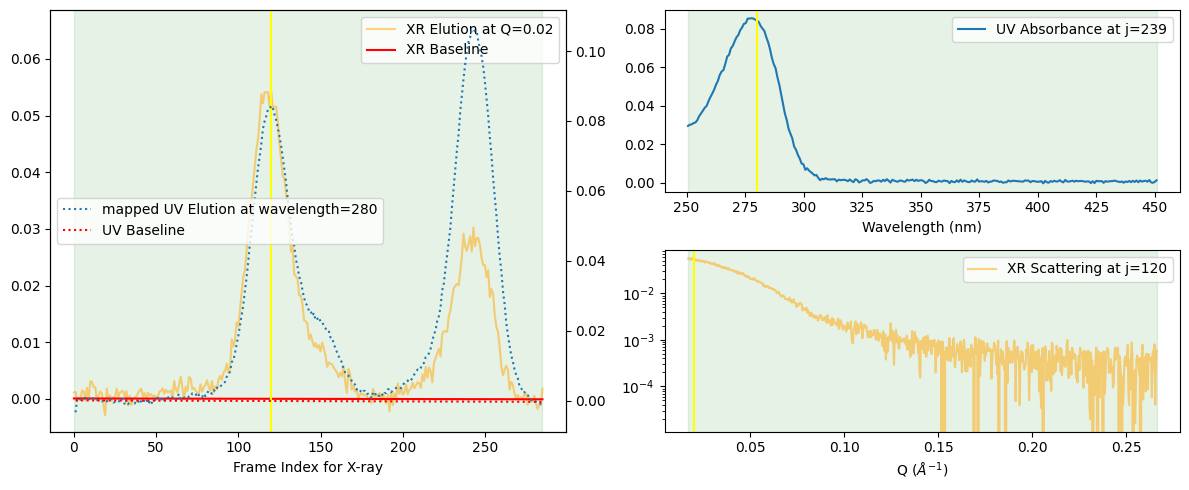

In [2]:
trimmed_ssd = ssd.trimmed_copy()
corrected_ssd = trimmed_ssd.corrected_copy()
corrected_ssd.plot_compact(baseline=True);

To change the correction method, you can use `set_baseline_method` with one of the following specification.

```python
ssd.set_baseline_method('linear')    # default setting
ssd.set_baseline_method(('linear', 'uvdiff'))
ssd.set_baseline_method('integral')
```

## UV-specific Correction

From our experience, it is known that baselines for UV data are often not linear. To address this peculiarity, you can change the method for UV data only as follows.

`set_baseline_method` interprets the first element of the tuple as the method for X-ray data and the second as the method for UV data.

```{note}
We won't explain the details of this UV-specific baseline in this tutorial. It is planned to be described in [Molass Technical Report](https://freesemt.github.io/molass-technical/).
```

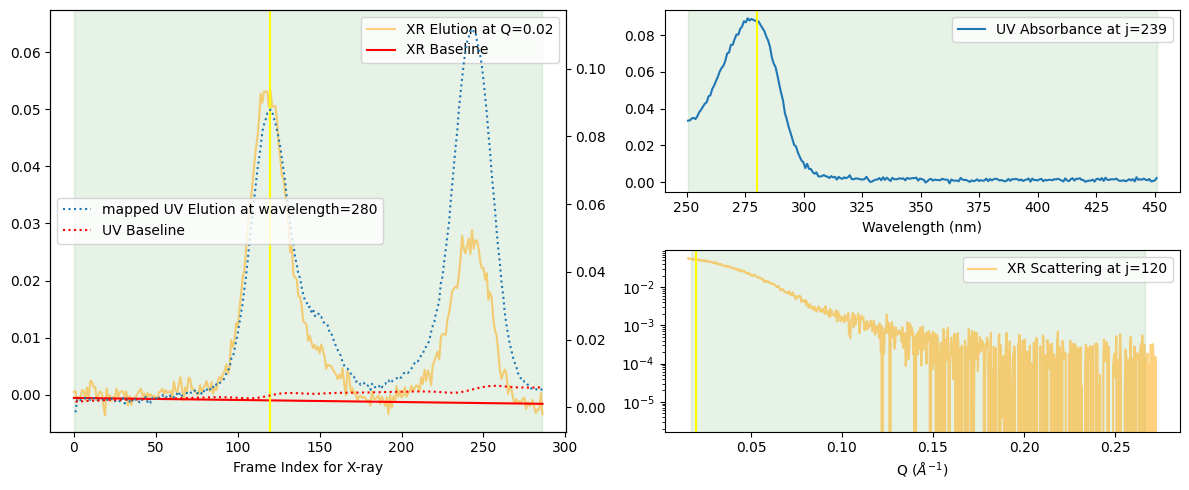

In [7]:
ssd.set_baseline_method(('linear', 'uvdiff'))
ssd.plot_compact(baseline=True);

The baseline method setting is retained with copies so that the following standard code sequence work as expected.

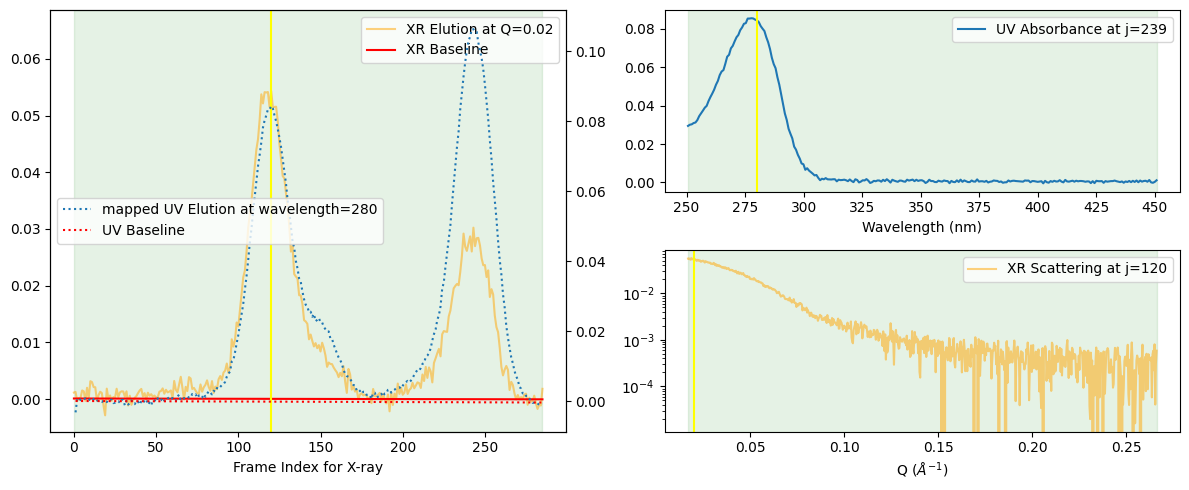

In [8]:
trimmed_ssd = ssd.trimmed_copy()
corrected_ssd = trimmed_ssd.corrected_copy()
corrected_ssd.plot_compact(baseline=True);

In [9]:
corrected_ssd.get_baseline_method()

('linear', 'uvdiff')

## Integral Correction

There is another established method which deals with the baseline drift due to the accumulation of fouling. The integral method can be activated by specifying `integral`.

To contrast the difference, compare the following plots resulted from `linear` and `integral` methods.

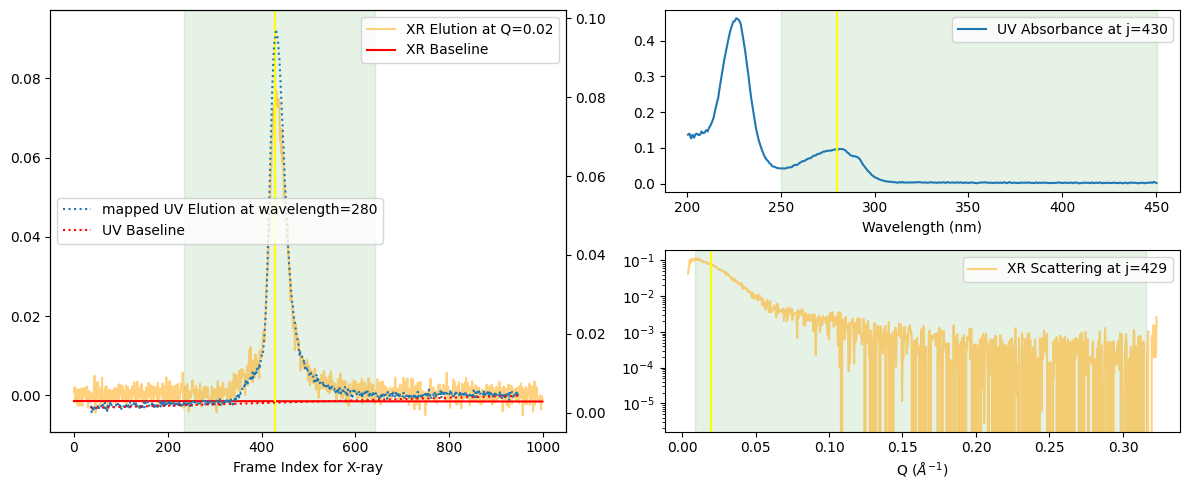

In [11]:
from molass_data import SAMPLE2
from molass.DataObjects import SecSaxsData as SSD
ssd2 = SSD(SAMPLE2)
ssd2.plot_compact(baseline=True);

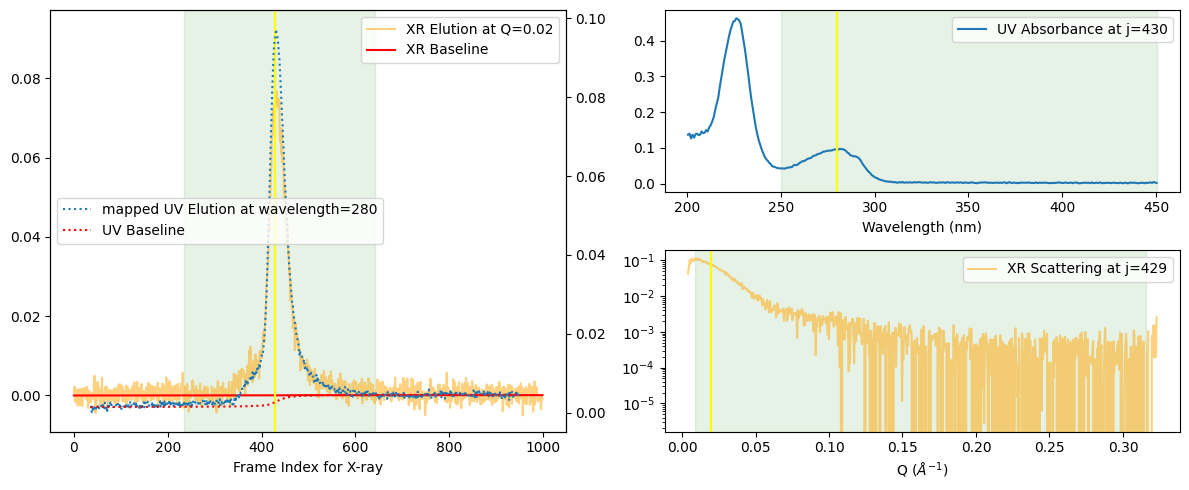

In [12]:
ssd2.set_baseline_method('integral')
ssd2.plot_compact(baseline=True);

In this case, difference is apparant only in UV baseline probably because the estimated fouling accumulation in X-ray data may have been ignorable.

Actual stardard correction procedure will be as follows.

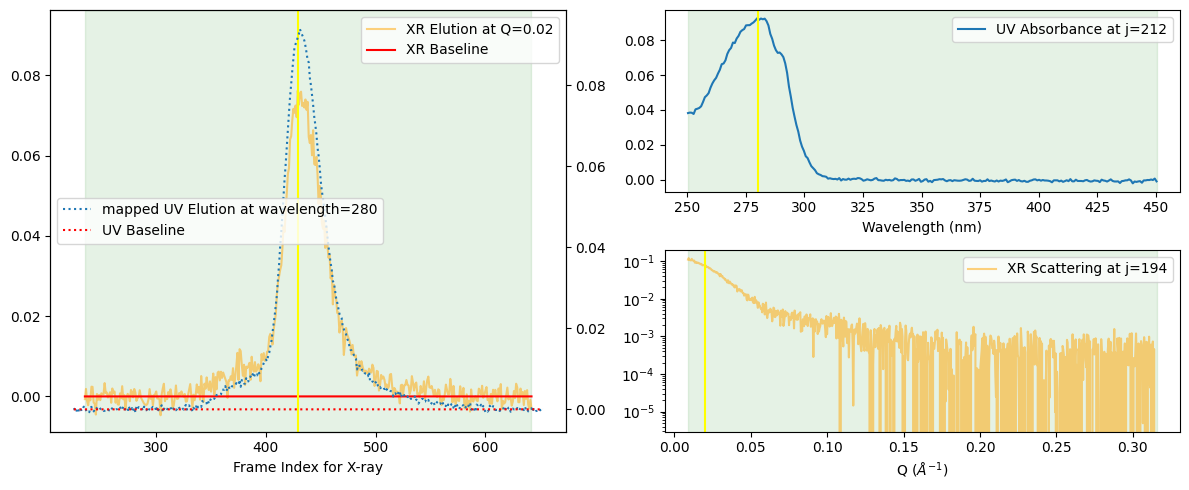

In [13]:
trimmed_ssd2 = ssd2.trimmed_copy()
corrected_ssd2 = trimmed_ssd2.corrected_copy()
corrected_ssd2.plot_compact(baseline=True);